In [15]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
from utils import detection_metrics, display_img, kaggle_submission

In [ ]:
glacier = cv2.imread("data/glacier.png", cv2.IMREAD_GRAYSCALE)
truth = cv2.imread("data/channels.png", cv2.IMREAD_GRAYSCALE)

mask = (truth == 0).astype(np.float32)

img = glacier.astype(np.float32) / 255.0

In [3]:
class GlacierPatchDataset(Dataset):
    def __init__(self, img, mask, patch_size=128, n_patches=3000):
        self.img = img
        self.mask = mask
        self.patch_size = patch_size
        self.n_patches = n_patches

    def __len__(self):
        return self.n_patches

    def __getitem__(self, idx):
        h, w = self.img.shape
        ps = self.patch_size

        y = random.randint(0, h - ps)
        x = random.randint(0, w - ps)

        patch = self.img[y:y+ps, x:x+ps]
        m = self.mask[y:y+ps, x:x+ps]

        # random flips
        if random.random() < 0.5:
            patch = np.fliplr(patch).copy()
            m = np.fliplr(m).copy()

        if random.random() < 0.5:
            patch = np.flipud(patch).copy()
            m = np.flipud(m).copy()

        patch = torch.tensor(patch[None, :, :], dtype=torch.float32)
        m = torch.tensor(m[None, :, :], dtype=torch.float32)

        return patch, m

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(1, 16)
        self.d2 = DoubleConv(16, 32)
        self.d3 = DoubleConv(32, 64)

        self.u2 = DoubleConv(64 + 32, 32)
        self.u1 = DoubleConv(32 + 16, 16)

        self.out = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        c1 = self.d1(x)
        p1 = F.max_pool2d(c1, 2)

        c2 = self.d2(p1)
        p2 = F.max_pool2d(c2, 2)

        c3 = self.d3(p2)

        u2 = F.interpolate(
            c3,
            size=c2.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        u2 = torch.cat([u2, c2], dim=1)
        u2 = self.u2(u2)

        u1 = F.interpolate(
            u2,
            size=c1.shape[2:],
            mode="bilinear",
            align_corners=False
        )
        u1 = torch.cat([u1, c1], dim=1)
        u1 = self.u1(u1)

        return self.out(u1)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

dataset = GlacierPatchDataset(img, mask, patch_size=128, n_patches=4000)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = SmallUNet().to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([8.0]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(15):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("epoch:", epoch + 1, "loss:", total_loss / len(loader))

cuda
epoch: 1 loss: 0.27786390054225923
epoch: 2 loss: 0.1369614205658436
epoch: 3 loss: 0.12984320843219757
epoch: 4 loss: 0.12453556218743324
epoch: 5 loss: 0.12194527968764306
epoch: 6 loss: 0.11680026814341544
epoch: 7 loss: 0.11327128693461418
epoch: 8 loss: 0.11010833126306534
epoch: 9 loss: 0.104938053637743
epoch: 10 loss: 0.10331468205153942
epoch: 11 loss: 0.09869687408208846
epoch: 12 loss: 0.09582354068756103
epoch: 13 loss: 0.09195362639427185
epoch: 14 loss: 0.09014867973327637
epoch: 15 loss: 0.08707016016542911


In [12]:
model.eval()

with torch.no_grad():
    x = torch.tensor(img[None, None, :, :], dtype=torch.float32).to(device)
    prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()

best_unet = (0, None, None)

for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    pred = (prob > t).astype("uint8") * 255

    vis, metrics = detection_metrics(pred, truth)
    score = float(metrics["f1_score"])

    print("threshold:", t, "score:", score)

    if score > best_unet[0]:
        best_unet = (score, t, pred)

print("BEST UNET:", best_unet[0], "threshold:", best_unet[1])

threshold: 0.1 score: 0.910542
threshold: 0.2 score: 0.920242
threshold: 0.3 score: 0.925463
threshold: 0.4 score: 0.927953
threshold: 0.5 score: 0.932184
threshold: 0.6 score: 0.93538
threshold: 0.7 score: 0.937172
threshold: 0.8 score: 0.92572
threshold: 0.9 score: 0.430957
BEST UNET: 0.937172 threshold: 0.7


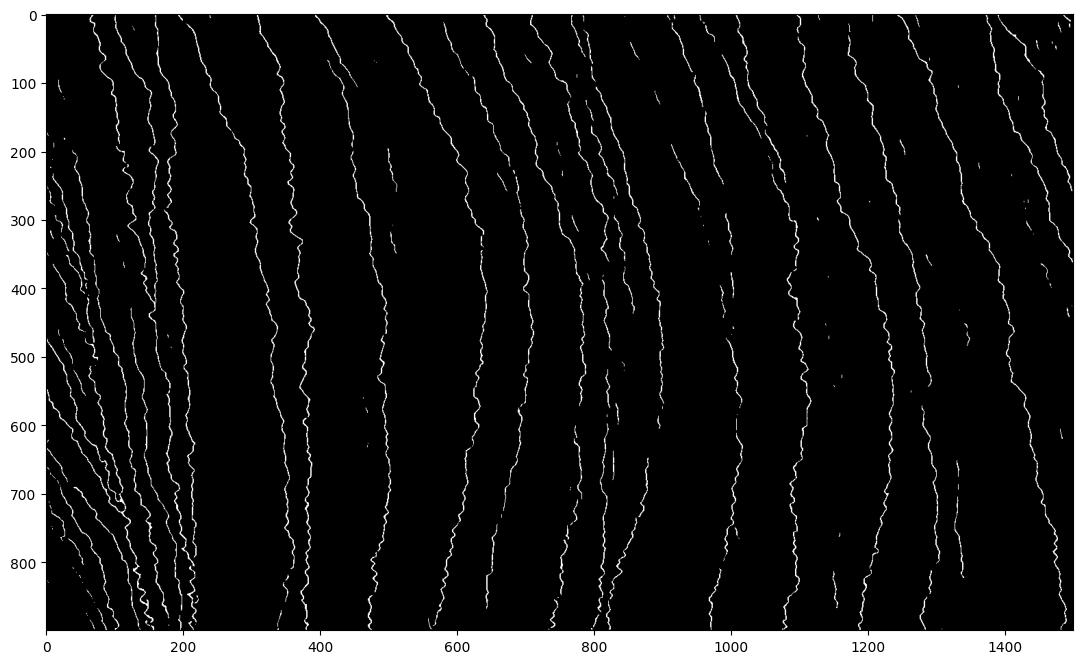

In [13]:
glacier_full = cv2.imread("data/glacier_FULL.png", cv2.IMREAD_GRAYSCALE)
img_full = glacier_full.astype(np.float32) / 255.0

model.eval()

with torch.no_grad():
    x = torch.tensor(img_full[None, None, :, :], dtype=torch.float32).to(device)
    prob_full = torch.sigmoid(model(x))[0, 0].cpu().numpy()

threshold = best_unet[1]
pred_full = (prob_full > threshold).astype("uint8") * 255

display_img(pred_full)

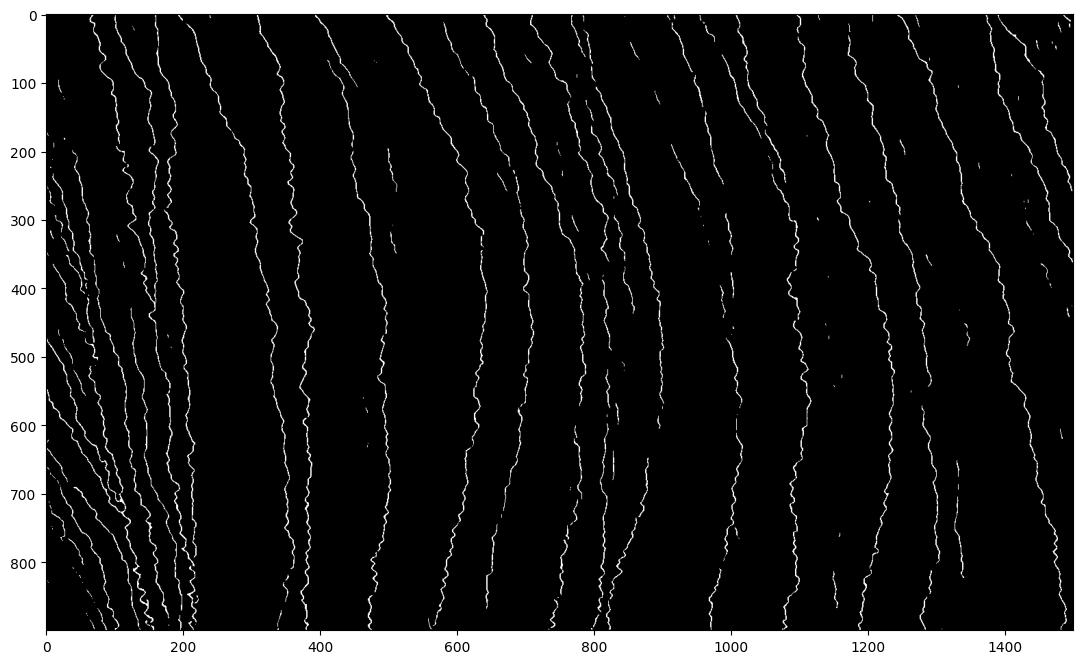

In [14]:
glacier_full = cv2.imread("data/glacier_FULL.png", cv2.IMREAD_GRAYSCALE)
img_full = glacier_full.astype(np.float32) / 255.0

model.eval()

with torch.no_grad():
    x_full = torch.tensor(img_full[None, None, :, :], dtype=torch.float32).to(device)
    prob_full = torch.sigmoid(model(x_full))[0, 0].cpu().numpy()

pred_full_unet = (prob_full > 0.7).astype("uint8") * 255

display_img(pred_full_unet)

In [16]:
kaggle_submission(pred_full_unet, "unet_threshold_07_submission.csv")

,row,0,1,2,3,4,5,6,7,8,...,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,896,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
896,897,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
897,898,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
898,899,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
